In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_palette('colorblind')

df = pd.read_csv('data/players_fc24_clean.csv')
df.shape

(18250, 56)

In [2]:
df['athleticism_index'] = df[['pace', 'movement_agility', 'power_stamina', 'power_strength']].mean(axis=1)

if df['work_rate'].str.contains('/').any():
    df[['work_rate_attack', 'work_rate_defense']] = df['work_rate'].str.split('/', expand=True)
    df = df.drop(columns=['work_rate'])
    cat_cols = ['preferred_foot', 'work_rate_attack', 'work_rate_defense']
else:
    cat_cols = ['preferred_foot', 'work_rate']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.shape

(18250, 60)

In [3]:
drop_for_model = ['short_name', 'player_positions', 'position_group']
X = df_encoded.drop(columns=drop_for_model)
y = df_encoded['position_group']

X.shape, y.value_counts()

((18250, 57),
 position_group
 Midfielder    6636
 Defender      6143
 Forward       3438
 Goalkeeper    2033
 Name: count, dtype: int64)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((14600, 57), (3650, 57))

In [5]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("NaNs in train:", X_train_scaled.isnull().sum().sum())
print("NaNs in test:", X_test_scaled.isnull().sum().sum())

NaNs in train: 0
NaNs in test: 0


## Classification Track — Part A

Reusing the cleaned FC24 dataset, target is `position_group` (Goalkeeper/Defender/Midfielder/
Forward), derived from each player's primary listed position. The same encoding approach as 
the Regression track is applied. The split is stratified to preserve class proportions given 
the moderate class imbalance observed in EDA (Midfielder 6,636 / Defender 6,143 / Forward 
3,438 / Goalkeeper 2,033).


In [6]:
models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Support Vector Machine (SVC)': SVC(C=10, kernel='rbf', random_state=42),
}

results_clf = []
trained_clf_models = {}

for name, model in models_clf.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results_clf.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})
    trained_clf_models[name] = model
    print(f"{name}: Accuracy={acc:.4f}, Weighted F1={f1:.4f}")

Logistic Regression: Accuracy=0.8964, Weighted F1=0.8964
K-Nearest Neighbors: Accuracy=0.8699, Weighted F1=0.8701
Naive Bayes (Gaussian): Accuracy=0.7921, Weighted F1=0.7912
Decision Tree Classifier: Accuracy=0.8474, Weighted F1=0.8474
Support Vector Machine (SVC): Accuracy=0.9068, Weighted F1=0.9065


In [7]:
results_clf_df = pd.DataFrame(results_clf).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_clf_df

,Model,Accuracy,Weighted F1
0,Support Vector Machine (SVC),0.906849,0.906528
1,Logistic Regression,0.896438,0.896396
2,K-Nearest Neighbors,0.869863,0.870115
3,Decision Tree Classifier,0.847397,0.847440
4,Naive Bayes (Gaussian),0.792055,0.791245


### Classification Part A — Model Comparison
Support Vector Machine (SVC) achieved the best performance (Accuracy=0.9068, Weighted 
F1=0.9065), followed closely by Logistic Regression (0.8964). This suggests the position 
classes are largely linearly separable given the skill attributes. Naive Bayes performed 
worst (Accuracy=0.7921), likely because its conditional independence assumption is violated — 
skill attributes are highly correlated with each other, as seen in the EDA correlation 
heatmap.

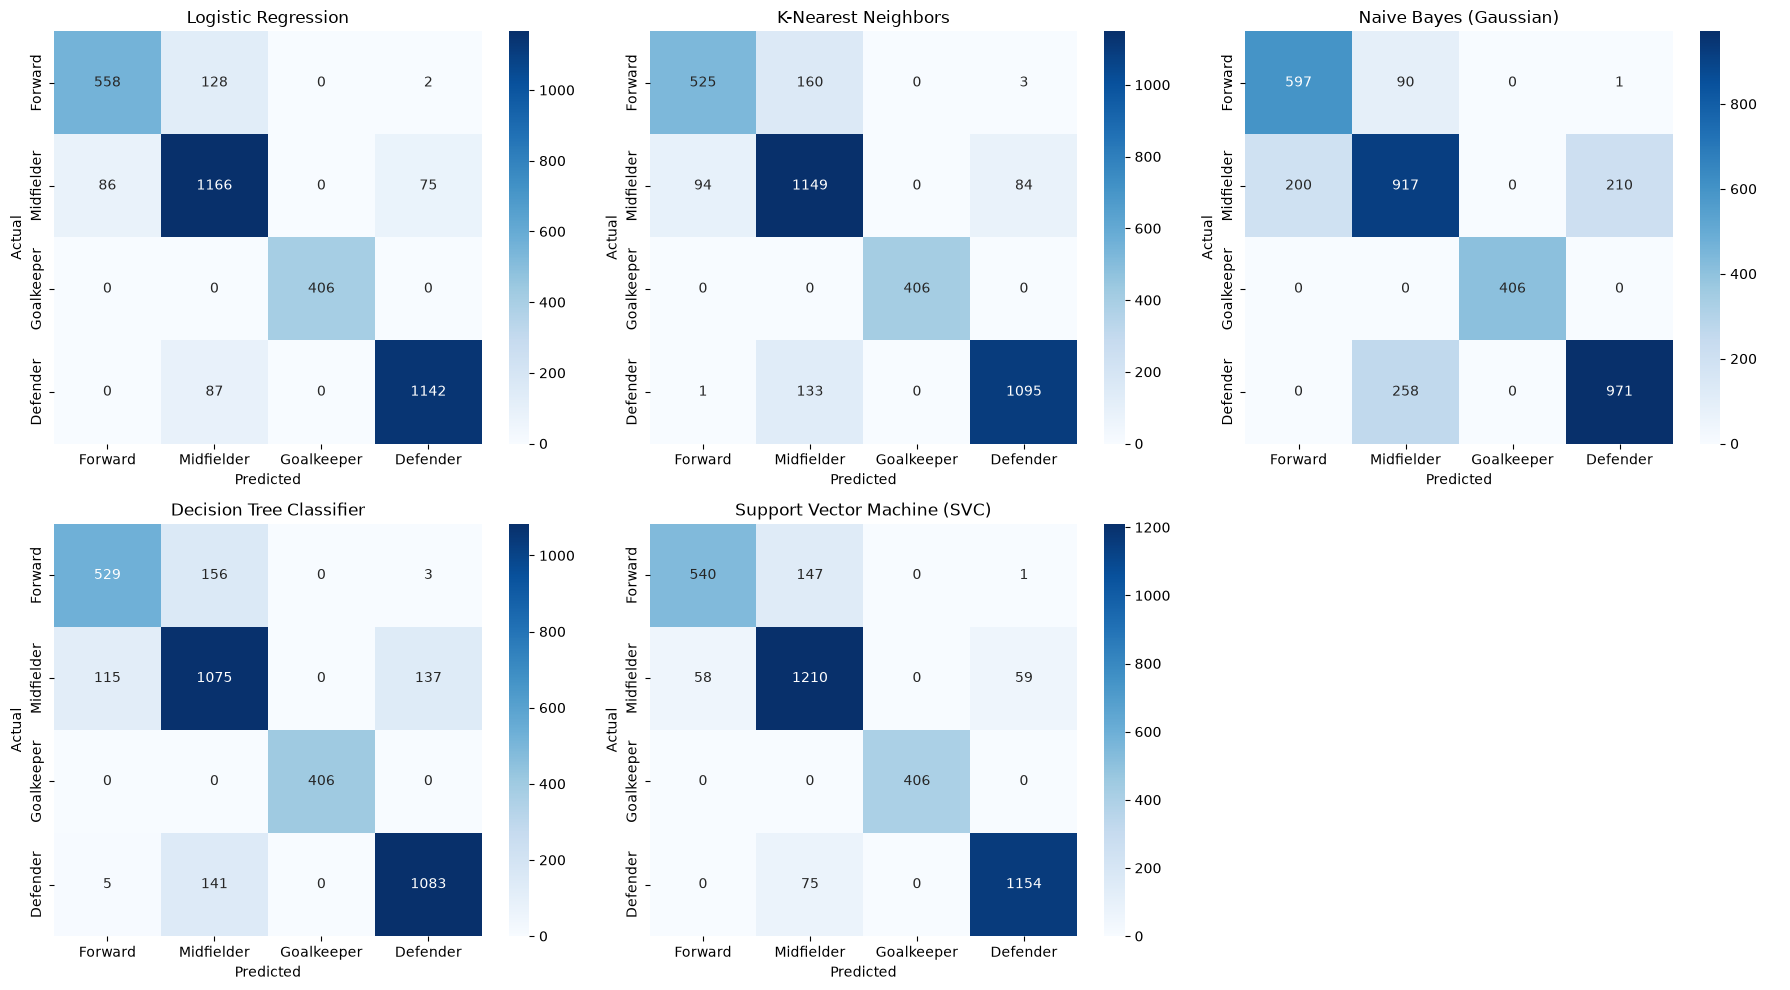

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_clf_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=y.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=y.unique(), yticklabels=y.unique())
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
plt.savefig('classification_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
### Confusion Matrices
All 5 models classify Goalkeepers with perfect or near-perfect accuracy — this is expected 
rather than surprising, since goalkeepers have their outfield skill attributes (pace, 
shooting, passing, dribbling, defending, physic) imputed to 0 during cleaning, making them 
trivially separable from outfield players. The main source of confusion across all models 
is between Midfielder and Defender/Forward, reflecting realistic overlap in skill profiles — 
e.g. box-to-box or defensive midfielders share attributes with defenders, while attacking 
midfielders share attributes with forwards.

In [9]:
best_name = results_clf_df.iloc[0]['Model']
best_model = trained_clf_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, y_pred_best))

Classification Report — Support Vector Machine (SVC)

              precision    recall  f1-score   support

    Defender       0.95      0.94      0.94      1229
     Forward       0.90      0.78      0.84       688
  Goalkeeper       1.00      1.00      1.00       406
  Midfielder       0.84      0.91      0.88      1327

    accuracy                           0.91      3650
   macro avg       0.92      0.91      0.92      3650
weighted avg       0.91      0.91      0.91      3650



### Classification Report — Support Vector Machine (SVC)
The SVM achieves strong precision and recall across all classes, with Goalkeeper reaching a 
perfect 1.00 across precision, recall, and F1. Forward shows the lowest recall (0.78), 
meaning some actual forwards are misclassified as midfielders — consistent with the 
confusion matrix pattern. Weighted average F1 of 0.91 confirms solid overall performance 
given the moderate class imbalance.